In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Load image
image = cv2.imread('/content/drive/MyDrive/datasets/chair-white-wall.jpeg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

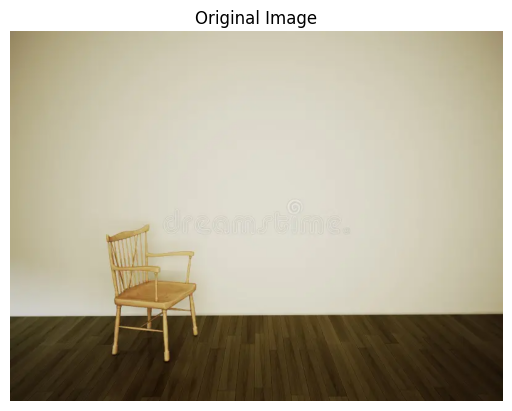

In [6]:
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

Thresholding Segmentation

 Converts image into binary (foreground vs background)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

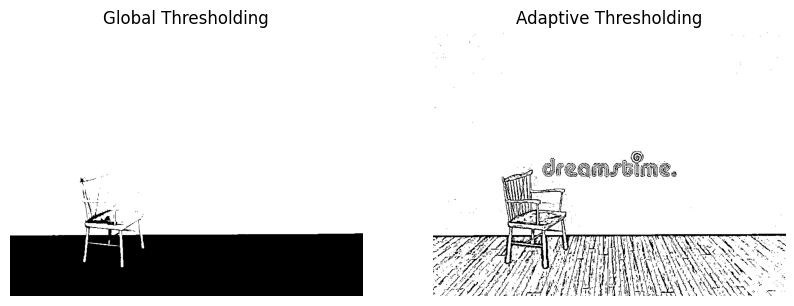

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Global Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding (better for lighting variation)
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(thresh, cmap='gray')
plt.title("Global Thresholding")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis('off')

Region-Based Segmentation (Watershed)

Groups similar regions (chair vs background)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

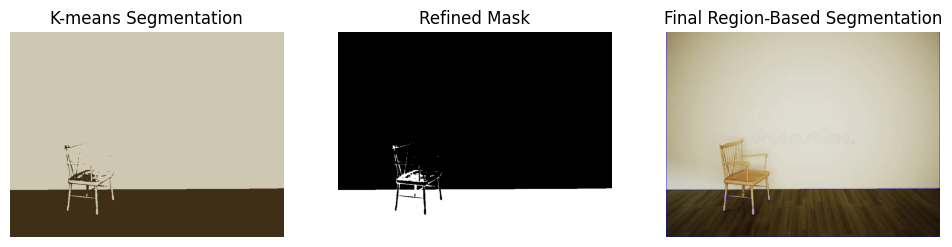

In [10]:
# Step 1: Convert to RGB for clustering
img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
Z = img.reshape((-1,3))
Z = np.float32(Z)

# Step 2: K-means clustering (2 clusters: chair vs background)
K = 2
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convert back
centers = np.uint8(centers)
segmented = centers[labels.flatten()]
segmented_image = segmented.reshape((img.shape))

# Step 3: Convert clustered image to grayscale
gray_seg = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2GRAY)

# Step 4: Threshold to isolate object
_, thresh = cv2.threshold(gray_seg, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Step 5: Morphological cleaning
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 6: Distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4*dist_transform.max(), 255, 0)

# Step 7: Background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 8: Marker labeling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Step 9: Watershed
markers = cv2.watershed(image, markers)

# Step 10: Draw boundaries
final_result = image.copy()
final_result[markers == -1] = [255, 0, 0]

# Show results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(segmented_image)
plt.title("K-means Segmentation")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Refined Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
plt.title("Final Region-Based Segmentation")
plt.axis('off')

Edge-Based Segmentation (Canny Edge Detection)

Detects object boundaries (chair edges clearly)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

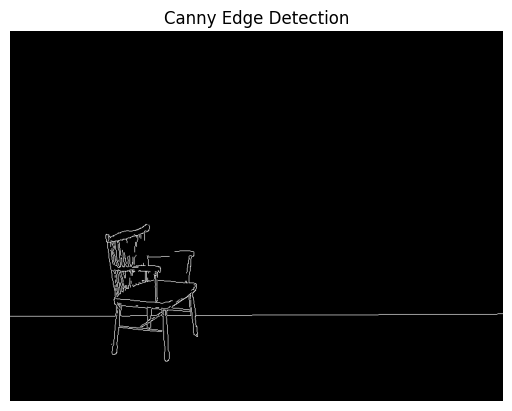

In [11]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')